In [2]:
import easyocr

In [32]:
reader = easyocr.Reader(['en'])
results = reader.readtext("D:\LENOVO\Downloads\WhatsApp Image 2026-06-20 at 00.59.23.jpeg", detail=0)

for line in results:
    print(line)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\LENOVO\Desktop\OCR project\.venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


DJECAlHLIN Halays # Sclr Bhd
P
'2001401634750,
~DECATHON KL,East Mall
V2
20
KL' Fast Mal
3
JaTan
gkaran
ergan 2
53100" Kua Ia Lumpur
Poon
Gucx ES SpXRIT OLAC
57481419
69,00
Seria
Hlbset"
DQo0co218569
TOTAL
39,01
Article(s)
Credit Card
59,00
Loyalty Card Number
20941950887193
Dank  Informal 1On For=
2007204/0223720-0
T IMe
13/ Jruv/2026  18.49*43
'00ooo9346656927
BATCH NO; 00o710
indLcuOno uoooooq ,
TERMINA "IO: 20317853
a
phan
Backaoaon
DECATHLON
810849 -
Ctrl
@AE/
MIA :


In [33]:
# Clean up the raw results
cleaned = []
for line in results:
    line = line.strip()
    if len(line) > 2:          # drop single chars / stray symbols
        cleaned.append(line)

for line in cleaned:
    print(line)

DJECAlHLIN Halays # Sclr Bhd
'2001401634750,
~DECATHON KL,East Mall
KL' Fast Mal
JaTan
gkaran
ergan 2
53100" Kua Ia Lumpur
Poon
Gucx ES SpXRIT OLAC
57481419
69,00
Seria
Hlbset"
DQo0co218569
TOTAL
39,01
Article(s)
Credit Card
59,00
Loyalty Card Number
20941950887193
Dank  Informal 1On For=
2007204/0223720-0
T IMe
13/ Jruv/2026  18.49*43
'00ooo9346656927
BATCH NO; 00o710
indLcuOno uoooooq ,
TERMINA "IO: 20317853
phan
Backaoaon
DECATHLON
810849 -
Ctrl
@AE/
MIA :


In [64]:
results_detail_test = reader.readtext("D:\LENOVO\Downloads\WhatsApp Image 2026-06-20 at 00.59.23.jpeg", detail=1)

for bbox, text, conf in results_detail_test:
    print(f"{bbox} {conf:.2f}  {text}")

c:\Users\LENOVO\Desktop\OCR project\.venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[[np.int32(287), np.int32(281)], [np.int32(545), np.int32(281)], [np.int32(545), np.int32(319)], [np.int32(287), np.int32(319)]] 0.07  DJECAlHLIN Halays # Sclr Bhd
[[np.int32(8), np.int32(302)], [np.int32(40), np.int32(302)], [np.int32(40), np.int32(334)], [np.int32(8), np.int32(334)]] 0.40  P
[[np.int32(297), np.int32(303)], [np.int32(423), np.int32(303)], [np.int32(423), np.int32(339)], [np.int32(297), np.int32(339)]] 0.10  '2001401634750,
[[np.int32(305), np.int32(321)], [np.int32(527), np.int32(321)], [np.int32(527), np.int32(358)], [np.int32(305), np.int32(358)]] 0.03  ~DECATHON KL,East Mall
[[np.int32(298), np.int32(352)], [np.int32(326), np.int32(352)], [np.int32(326), np.int32(376)], [np.int32(298), np.int32(376)]] 0.17  V2
[[np.int32(356), np.int32(348)], [np.int32(386), np.int32(348)], [np.int32(386), np.int32(374)], [np.int32(356), np.int32(374)]] 0.97  20
[[np.int32(394), np.int32(343)], [np.int32(508), np.int32(343)], [np.int32(508), np.int32(373)], [np.int32(394), np.int3

In [26]:
import re

amounts = []
for bbox, text, conf in results_detail:
    matches = re.findall(r'\d+[.,]\d{2}', text)
    for m in matches:
        amounts.append((float(m.replace(',', '.')), text, conf))
        #print(matches, text,conf)
        #print(amounts) #goes line by line the result_detail item

# highest amount is likely the total
amounts.sort(reverse=True)
print("Likely total:", amounts[0])

Likely total: (69.0, '69,00', np.float64(0.7836806658252163))


Above wont work:

Intended work:
first lets do a condition to retrieve the total, maybe something like,  first closest to word total, second accuracy: it need to grab the one with highest conf



Example: 39.01 is the closest but the accuracy is lower so it capture the highest accuracy with closest one

Current work: Fix the upstream, get the model to read it correctly

1. Preprocessing image

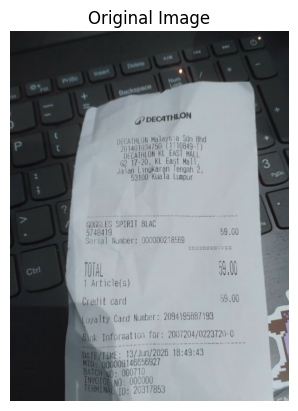

In [44]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"D:\LENOVO\Downloads\WhatsApp Image 2026-06-20 at 00.59.23.jpeg")
#img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
#img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]  # binarize

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

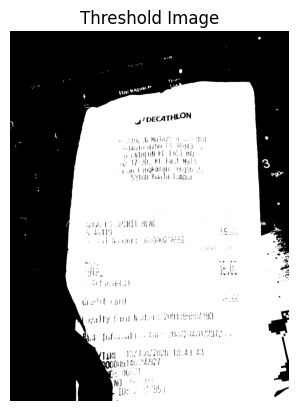

In [43]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"D:\LENOVO\Downloads\WhatsApp Image 2026-06-20 at 00.59.23.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]  # binarize

plt.imshow(img, cmap="gray")
plt.title("Threshold Image")
plt.axis("off")
plt.show()

In [36]:
import cv2
import numpy as np

img = cv2.imread("D:\LENOVO\Downloads\WhatsApp Image 2026-06-20 at 00.59.23.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)  # upscale
img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]  # binarize

reader = easyocr.Reader(['en'])
results1 = reader.readtext(img, detail=1)

for bbox, text, conf in results1:
    print(f"{conf:.2f}  {text}")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


0.05  Mll ; Mit#:
0.13  4h|
0.17  ']4/ :il
0.19  it4 )
0.12  ATHlN kl
0.29  Foi
0.99  ML
0.14  p|
0.97  d,
0.42  Ma} !
1.00  3
0.10  H al &
0.14  {4Jvh
0.14  Iul) Ktkcl |l
0.11  'IlJ6 4 /
0.22  '16,4,
0.02  .SR] |
0.14  !L AC
0.55  41/'
0.17  1.i 'Wjl:l
0.19  {nWi06
0.13  K6
0.09  'Vlw,iela)
0.05  L 'll 'ard
0.08  valty ( Mk,li: 0.'4
0.16  Jlf,ivtl
0.11  Xwi
0.09  :'I;73,4470;231 2.,
0.35  i
0.88  1"
0.14  48X"{j
0.45  13.4 4
0.02  @Q6Jx |46 ,86,12 7
0.19  {J : 1
0.85  N)
0.90  [:
0.08  Krimn"
0.07  (nt
0.48  DECATFILON
0.40  J)


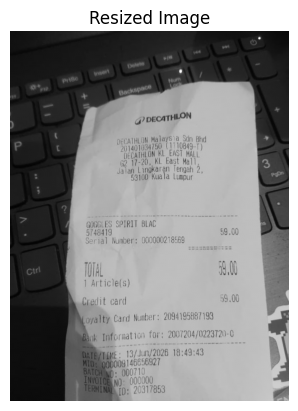

In [41]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"D:\LENOVO\Downloads\WhatsApp Image 2026-06-20 at 00.59.23.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

plt.imshow(img, cmap="gray")
plt.title("Resized Image")
plt.axis("off")
plt.show()


In [38]:
import cv2
import numpy as np

img = cv2.imread("D:\LENOVO\Downloads\WhatsApp Image 2026-06-20 at 00.59.23.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)  # upscale
#img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]  # binarize

reader = easyocr.Reader(['en'])
results = reader.readtext(img, detail=1)

for bbox, text, conf in results:
    print(f"{conf:.2f}  {text}")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\LENOVO\Desktop\OCR project\.venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.08  DJECAIHLIJ Malays # Stlr Bhd
0.30  p
0.24  0
0.05  '201401034750 ( E300849-7)
0.04  DECATHLON KL_ FaSt  Mall
0.59  62 17-20
0.45  KL Fast Mal
1.00  3
0.26  Jatan L Ingkaran
0.36  (erigan
0.51  53100 Kua Ta
0.84  Lumpur
0.23  Poon
0.63  7
0.19  7
0.13  GucEs SpyRit  OLAC
0.40  57481419
0.83  59,00
0.17  Serial Mumber : 0(000o2t8569
0.93  TOTAL
0.11  59,00
0.55  1 Articiels)
0.51  Credit Card
0.99  59,00
0.71  Loyalty Card Number : 2094195087193
0.54  Bank Informat1On  For : 2007204/0223720-0
0.11  @ate/T [ME :
0.48  13/ Jurv/2026  18.49*43
0.08  ooooc9|46656927
0.27  NO; 000710
0.03  Invoice"No
0.28  'Qooooo_
0.64  ID: 20317853
0.53  D
0.02  H
0.04  Foa
0.37  Backapacn
0.71  G) DECATHLON
0.49  Gtrl
0.19  MIo :
0.33  BATCh
0.34  TERMINAL ^


In [91]:
import re

TOTAL_KEYWORDS = ['total', 'jumlah', 'amaun', 'debit card', 'kredit card', 'credit card']
AMOUNT_PATTERN = r'\d+[.,]\d{2}'

# separate into two lists
keyword_lines = []
amount_lines = []

for bbox, text, conf in results:
    top_y = min(p[1] for p in bbox)
    if any(kw in text.lower() for kw in TOTAL_KEYWORDS):
        keyword_lines.append((top_y, text))
    if re.search(AMOUNT_PATTERN, text):
        amount_lines.append((top_y, text, conf))

# for each keyword hit, find the closest amount by y-position
for kw_y, kw_text in keyword_lines:
    closest = min(amount_lines, key=lambda x: abs(x[0] - kw_y))
    amount = re.search(AMOUNT_PATTERN, closest[1]).group()

    #amount = closest[1]

    print(f"Keyword : {kw_text}")
    print(f"Total   : {amount}  (conf: {closest[2]:.2f})")
    print()

Keyword : TOTAL
Total   : 59,00  (conf: 0.11)

Keyword : Credit Card
Total   : 59,00  (conf: 0.99)



Below using un preprocessed image

In [92]:
import re

TOTAL_KEYWORDS = ['total', 'jumlah', 'amaun', 'debit card', 'kredit card', 'credit card']
AMOUNT_PATTERN = r'\d+[.,]\d{2}'

# separate into two lists
keyword_lines = []
amount_lines = []

for bbox, text, conf in results_detail_test:
    top_y = min(p[1] for p in bbox)
    if any(kw in text.lower() for kw in TOTAL_KEYWORDS):
        keyword_lines.append((top_y, text))
        #print(keyword_lines)
    if re.search(AMOUNT_PATTERN, text):
        amount_lines.append((top_y, text, conf))
        #print(min(amount_lines))
        #print(amount_lines)

# for each keyword hit, find the closest amount by y-position
for kw_y, kw_text in keyword_lines:
    closest = min(amount_lines, key=lambda x: abs(x[0] - kw_y))
    amount = re.search(AMOUNT_PATTERN, closest[1]).group()
    #print(closest)
    #print(closest[1])
    #print(amount)

    #amount = closest[1]
    
    print(f"Keyword : {kw_text}")
    print(f"Total   : {amount}  (conf: {closest[2]:.2f})")
    print()

Keyword : TOTAL
Total   : 39,01  (conf: 0.10)

Keyword : Credit Card
Total   : 59,00  (conf: 0.99)



In [94]:
import cv2
import numpy as np

img = cv2.imread("d:\LENOVO\Downloads\WhatsApp Image 2026-06-23 at 13.32.28.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)  # upscale
#img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]  # binarize

reader = easyocr.Reader(['en'])
results = reader.readtext(img, detail=1)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


c:\Users\LENOVO\Desktop\OCR project\.venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [95]:
import re

TOTAL_KEYWORDS = ['total', 'jumlah', 'amaun', 'debit card', 'kredit card', 'credit card']
AMOUNT_PATTERN = r'\d+[.,]\d{2}'

# separate into two lists
keyword_lines = []
amount_lines = []

for bbox, text, conf in results:
    top_y = min(p[1] for p in bbox)
    if any(kw in text.lower() for kw in TOTAL_KEYWORDS):
        keyword_lines.append((top_y, text))
    if re.search(AMOUNT_PATTERN, text):
        amount_lines.append((top_y, text, conf))

# for each keyword hit, find the closest amount by y-position
for kw_y, kw_text in keyword_lines:
    closest = min(amount_lines, key=lambda x: abs(x[0] - kw_y))
    amount = re.search(AMOUNT_PATTERN, closest[1]).group()

    #amount = closest[1]

    print(f"Keyword : {kw_text}")
    print(f"Total   : {amount}  (conf: {closest[2]:.2f})")
    print()

Keyword : Total Saving
Total   : 10.22  (conf: 1.00)

Keyword : Total
Total   : 40.88  (conf: 1.00)

Keyword : DEBIT CARD
Total   : 40.90  (conf: 1.00)

